# Secrets of Darkwood — Gaming Product Analytics

**Objective.** Evaluate real-money monetization and in-game purchasing behavior, and determine
which product changes can be validated experimentally on this audience.

**Data.** 22,214 registered players, 1,307,678 purchase transactions (PostgreSQL, schema `fantasy`).

**A note on units.** The game runs on a premium currency, *paradise petals*, earned through
quests or bought for real money. The `amount` field records spend **in petals, not in real money**.
The only revenue-bearing field in the schema is the binary `payer` flag. Buyers (players who
spend petals) and payers (players who buy petals for money) are distinct populations.

**Key findings.**
1. 17.7% of registered players convert to real-money payers.
2. Race has **no** effect on conversion ($\chi^2$ = 3.64, df = 6, p = 0.72) — the 17.1–19.4% spread is noise.
3. Spend is extremely heavy-tailed (CV $\approx$ 4.8); the mean is not a usable summary.
4. Two items account for the overwhelming majority of demand.
5. Conversion is testable experimentally (MDE 1.43 pp); mean spend is not, at this audience size.

**Sections.** 1) conversion · 2) purchasing behavior · 3) race balance · 4) metric validation

## 1. Player Monetization Analysis

### Objective

The objective of this analysis is to evaluate player monetization in the game
*Secrets of Darkwood*.

The analysis focuses on:

- estimating the overall share of paying players;
- comparing payer conversion across character races;
- testing whether payer conversion depends on the character race the player chose.

The analysis is based on registered players and their payment status.

### 1.1 Overall Payer Share

First, we estimate the overall share of paying players among all registered
players.

A player is considered a payer if their `payer` indicator equals 1.

The metric is calculated as:

$$
\text{Payer Share} =
\frac{\text{Number of Paying Players}}
{\text{Total Number of Registered Players}}
$$

This metric provides a baseline for evaluating the overall monetization level
of the player base.

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

In [93]:
overall_monetization = pd.read_csv(
    "overall_monetization.csv"
)

monetization_by_race = pd.read_csv(
    "monetization_by_race.csv"
)

In [94]:
overall_monetization

,players_total,payers_total,payer_share
0,22214,3929,0.177


The overall payer share is approximately 17.7%, meaning that fewer than one
in five registered players made at least one payment.

### 1.2 Payer Share by Character Race

Next, we compare the payer share across character races.

This analysis helps identify whether player character characteristics are
associated with differences in monetization behavior.

For each race, we calculate:

- the number of paying players;
- the total number of registered players;
- the share of paying players.

The payer share is calculated as:

$$
\text{Payer Share}_{race} =
\frac{\text{Paying Players}_{race}}
{\text{Registered Players}_{race}}
$$

Point estimates alone cannot answer whether race matters: group sizes range from 1,229 to
6,328 players, so smaller races vary more by chance. The observed spread is therefore tested
for significance rather than ranked.

In [95]:
monetization_by_race

,race,payers_race,players_race,payer_share
0,Demon,238,1229,0.194
1,Hobbit,659,3648,0.181
2,Human,1114,6328,0.176
3,Northman,626,3562,0.176
4,Orc,636,3619,0.176
5,Angel,229,1327,0.173
6,Elf,427,2501,0.171


In [96]:
from scipy import stats

# Contingency table: payers vs non-payers per race.
# Check whether conversion DEPENDS on race — that is a hypothesis about
# independence, not a ranking exercise, so it needs a test rather than a sort.
contingency = monetization_by_race.assign(
    non_payers=lambda d: d["players_race"] - d["payers_race"]
)[["payers_race", "non_payers"]].values

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2 = {chi2:.2f}, df = {dof}, p_value = {p_value:.4f}")

# Largest observed gap, tested directly
demon = contingency[monetization_by_race["race"].values == "Demon"][0]
rest = contingency[monetization_by_race["race"].values != "Demon"].sum(axis=0)
print(f"Demon vs all others: p_value = {stats.chi2_contingency([demon, rest])[1]:.4f}")

chi2 = 3.64, df = 6, p_value = 0.7248
Demon vs all others: p_value = 0.1216


In [97]:
plot_data = monetization_by_race.sort_values(
    "payer_share",
    ascending=True
)

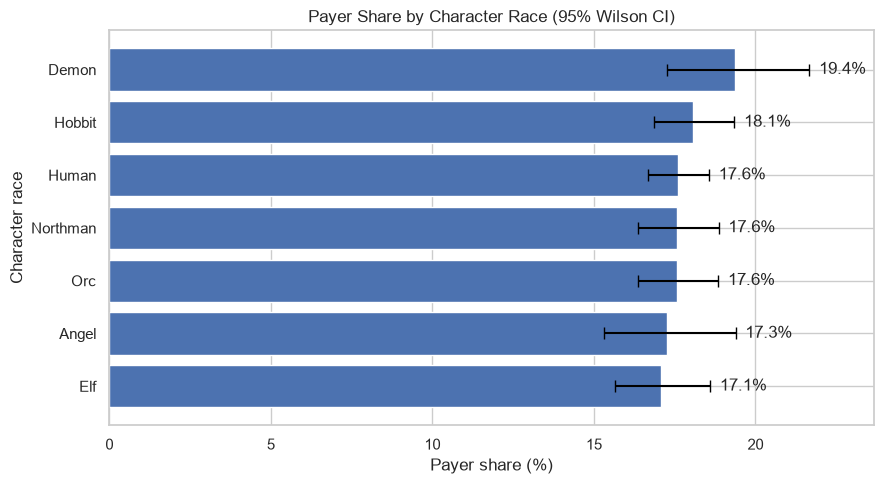

In [98]:
# Wilson score interval — appropriate for proportions with small groups,
# unlike the normal approximation which misbehaves in the tails.
import numpy as np

z = 1.96
p = plot_data["payer_share"].to_numpy()
n = plot_data["players_race"].to_numpy()
centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
lo, hi = centre - half, centre + half

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data["race"], p * 100)
ax.errorbar(p * 100, range(len(plot_data)),
            xerr=[(p - lo) * 100, (hi - p) * 100],
            fmt="none", ecolor="black", capsize=4)

ax.set_xlabel("Payer share (%)")
ax.set_ylabel("Character race")
ax.set_title("Payer Share by Character Race (95% Wilson CI)")
ax.set_xlim(0, hi.max() * 100 + 2)

for i, (val, h) in enumerate(zip(p * 100, hi * 100)):
    ax.text(h + 0.3, i, f"{val:.1f}%", va="center")

plt.tight_layout()
plt.savefig("../images/payer_share_by_race.png", dpi=150)
plt.show()

### Key Findings

- Overall real-money conversion is **17.7%** (3,929 of 22,214 registered players).
- Payer share by race spans 17.1% (Elf) to 19.4% (Demon), but a chi-squared test of
  independence gives **χ² = 3.64, df = 6, p = 0.72**. The null hypothesis of independence is
  not rejected: **race does not predict real-money conversion.**
- The apparent Demon advantage does not survive testing (p = 0.12 versus all other races
  pooled). It is an artifact of sample size — Demons are the smallest group at 1,229 players,
  giving the widest confidence interval and the most room for random variation.
- **Implication:** race is not a usable targeting axis for monetization campaigns. Ranking
  seven point estimates without a significance test would have produced the opposite — and
  wrong — recommendation.

## 2. In-Game Purchase Analysis

### Objective

The objective of this analysis is to investigate purchasing behavior inside the
game *Secrets of Darkwood*.

The analysis focuses on:

- examining the distribution of purchase amounts;
- identifying potential anomalies in transaction data;
- analyzing the popularity of in-game items;
- understanding purchasing patterns across all recorded transactions.

These insights help evaluate player spending behavior and identify potential
product issues or opportunities for monetization improvements.

### 2.1 Purchase Amount Statistics

First, we examine the overall distribution of purchase amounts.

For all recorded transactions, we calculate:

- total number of transactions;
- total transaction value;
- minimum and maximum purchase amount;
- mean purchase amount;
- median purchase amount;
- standard deviation.

Comparing the mean and the median helps identify whether the purchase amount
distribution is symmetric or heavily skewed by expensive purchases.

In [99]:
purchase_statistics = pd.read_csv("purchase_statistics.csv")

purchase_statistics

,total_transactions,total_spend,min_purchase_amount,max_purchase_amount,avg_purchase_amount,median_purchase_amount,std_purchase_amount
0,1307678,686615040,0.000,"486,615.100",525.692,74.860,"2,517.345"


In [100]:
purchase_amounts = pd.read_csv(
    "purchase_amounts.csv"
)

purchase_amounts.head()

,amount
0,21.410
1,64.980
2,50.680
3,46.490
4,18.720


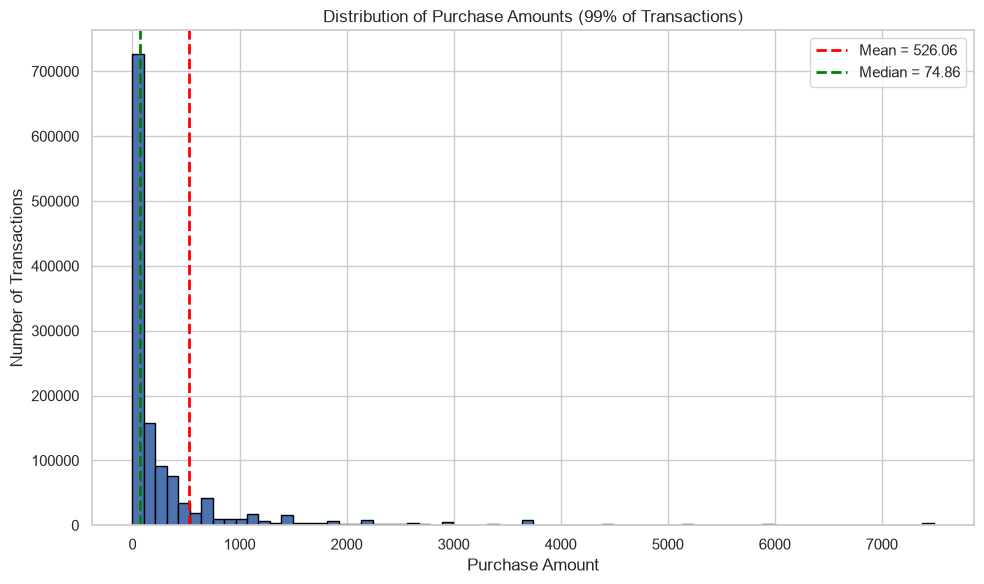

In [101]:
import matplotlib.pyplot as plt
import numpy as np

#99% of purchases
p99 = purchase_amounts["amount"].quantile(0.99)

filtered = purchase_amounts[
    purchase_amounts["amount"] <= p99
]

mean_value = purchase_amounts["amount"].mean()
median_value = purchase_amounts["amount"].median()

plt.figure(figsize=(10, 6))

plt.hist(
    filtered["amount"],
    bins=70,
    edgecolor="black"
)

plt.axvline(
    mean_value,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

plt.title("Distribution of Purchase Amounts (99% of Transactions)")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Transactions")

plt.legend()

plt.tight_layout()
plt.savefig("../images/purchase_distribution.png", dpi=150)
plt.show()

The histogram illustrates the distribution of purchase amounts for the lowest
99% of transactions.

The top 1% of purchases are excluded from the plot for readability. The mean and median lines
are computed on all non-zero transactions, the same population the histogram is drawn from.

Several important observations emerge:

- the distribution is strongly right-skewed;
- most purchases have relatively low values;
- a small number of expensive purchases substantially increase the arithmetic
  mean;
- the median provides a more representative estimate of a typical purchase.

### 2.2 Zero-Cost Transactions

Next, we investigate transactions with a purchase amount equal to zero.

Although these transactions do not generate revenue, they may indicate:

- promotional giveaways;
- system-generated rewards;
- data quality issues;
- logging or processing errors.

We calculate both the absolute number of zero-cost transactions and their
share among all recorded transactions.

In [102]:
zero_cost_transactions = pd.read_csv("zero_cost_transactions.csv")
display(zero_cost_transactions.style.format({"zero_cost_share": "{:.6f}"}))

,zero_cost_transactions,zero_cost_share
0,907,0.000694


In [103]:
zero_count = int(zero_cost_transactions.loc[0, "zero_cost_transactions"])
zero_share = zero_cost_transactions.loc[0, "zero_cost_share"] * 100

print(f"Zero-cost transactions: {zero_count:,}")
print(f"Share of all transactions: {zero_share:.4f}%")

Zero-cost transactions: 907
Share of all transactions: 0.0694%


Zero-cost transactions account for less than 0.1% of all recorded purchases.

Such transactions are therefore extremely rare and are unlikely to have a
material impact on the overall purchasing statistics.

Nevertheless, these transactions should be reviewed during data quality
checks, as they may represent promotional events, system rewards,
or data recording anomalies.

### 2.3 Most Popular Epic Items

Finally, we analyze the popularity of epic in-game items.

For each item, we calculate:

- the total number of purchase transactions;
- the share of all purchase transactions;
- the share of unique buyers who purchased the item.

This analysis helps identify which items dominate player purchases and may
represent the most successful monetization products.

In [104]:
popular_items = pd.read_csv("popular_items.csv")

popular_items.head()

,epic_item,total_transactions,transaction_share,buyer_share
0,Book of Legends,1004516,0.769,0.884
1,Bag of Holding,271875,0.208,0.868
2,Necklace of Wisdom,13828,0.011,0.118
3,Gems of Insight,3833,0.003,0.067
4,Treasure Map,3084,0.002,0.055


In [105]:
top10_items = popular_items.sort_values("buyer_share", ascending=False).head(10)

top10_items

,epic_item,total_transactions,transaction_share,buyer_share
0,Book of Legends,1004516,0.769,0.884
1,Bag of Holding,271875,0.208,0.868
2,Necklace of Wisdom,13828,0.011,0.118
3,Gems of Insight,3833,0.003,0.067
4,Treasure Map,3084,0.002,0.055
5,Silver Flask,795,0.001,0.046
6,Amulet of Protection,1078,0.001,0.032
7,Glowing Pendant,563,0.000,0.026
8,Strength Elixir,580,0.000,0.024
9,Ring of Wisdom,379,0.000,0.022


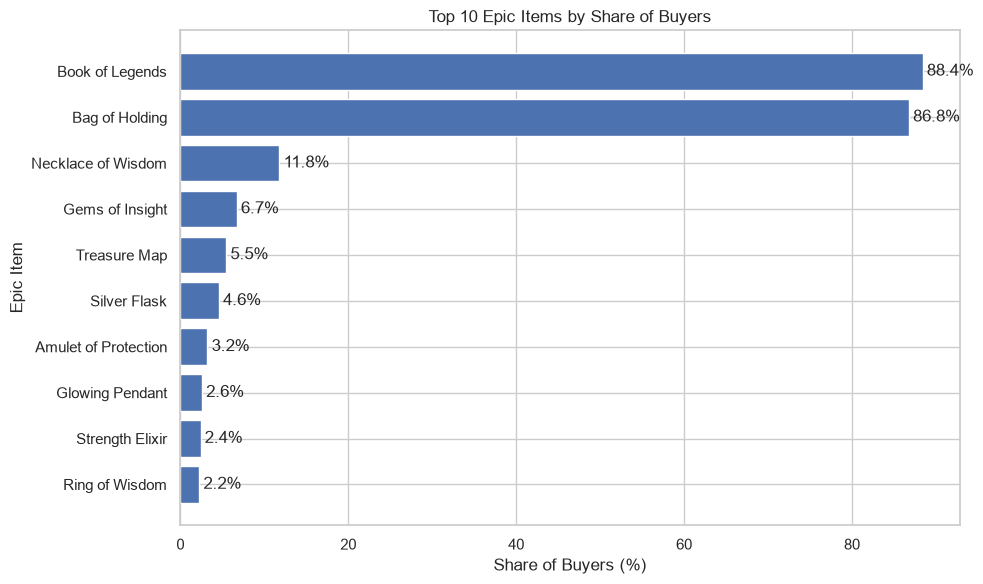

In [106]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_items["epic_item"],
    top10_items["buyer_share"] * 100
)

plt.xlabel("Share of Buyers (%)")
plt.ylabel("Epic Item")
plt.title("Top 10 Epic Items by Share of Buyers")

plt.gca().invert_yaxis()

for i, value in enumerate(top10_items["buyer_share"] * 100):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.savefig("../images/top_epic_items.png", dpi=150)
plt.show()

The popularity of epic items is highly concentrated.

Two items — **Book of Legends** and **Bag of Holding** — dominate player
purchases, with both being bought by more than 85% of all purchasing players.

The remaining items have substantially smaller buyer shares, indicating a
long-tail distribution of player demand across epic items.

This suggests that only a small number of products account for the majority
of player engagement with premium content.

### Key Findings

- Purchase amounts are highly right-skewed, with a small number of expensive
  transactions substantially increasing the average purchase value.
- The median purchase amount provides a more representative estimate of a
  typical transaction than the arithmetic mean.
- Zero-cost transactions account for less than 0.1% of all purchases and are
  unlikely to affect the overall purchasing statistics.
- Player demand for epic items is highly concentrated: two products dominate
  purchases, while the remaining items form a long tail with relatively low
  buyer shares.

## 3. Race Balance (Ad Hoc Request)

**Request.** The analytics team hypothesizes that some races are harder to play and therefore
require more epic item purchases to progress. The design goal is parity — no race should be
markedly easier or harder than another.

Note that this is a **game design** question, not a marketing segmentation question. Purchase
intensity is read here as a proxy for progression difficulty.

**Metrics per race:** registered players, buyers and buyer share, payer share among buyers,
purchases per buyer, average purchase amount, total spend per buyer.

In [107]:
race_activity = pd.read_csv("race_activity.csv")
race_activity

,race,total_registered_players,total_buyers,buyers_registered_share,payers_buyers_share,avg_purchases_per_buyer,avg_purchase_amount,spend_per_buyer
0,Human,6328,3921,0.620,0.180,121.402,403.055,"48,931.726"
1,Angel,1327,820,0.618,0.167,106.805,455.643,"48,664.922"
2,Hobbit,3648,2266,0.621,0.177,86.129,552.915,"47,621.917"
3,Northman,3562,2229,0.626,0.182,82.102,761.518,"62,521.999"
4,Orc,3619,2276,0.629,0.174,81.738,510.920,"41,761.631"
5,Elf,2501,1543,0.617,0.163,78.791,682.322,"53,760.570"
6,Demon,1229,737,0.600,0.199,77.870,529.020,"41,194.681"


In [108]:
from scipy import stats

players = pd.read_csv("player_spend.csv")

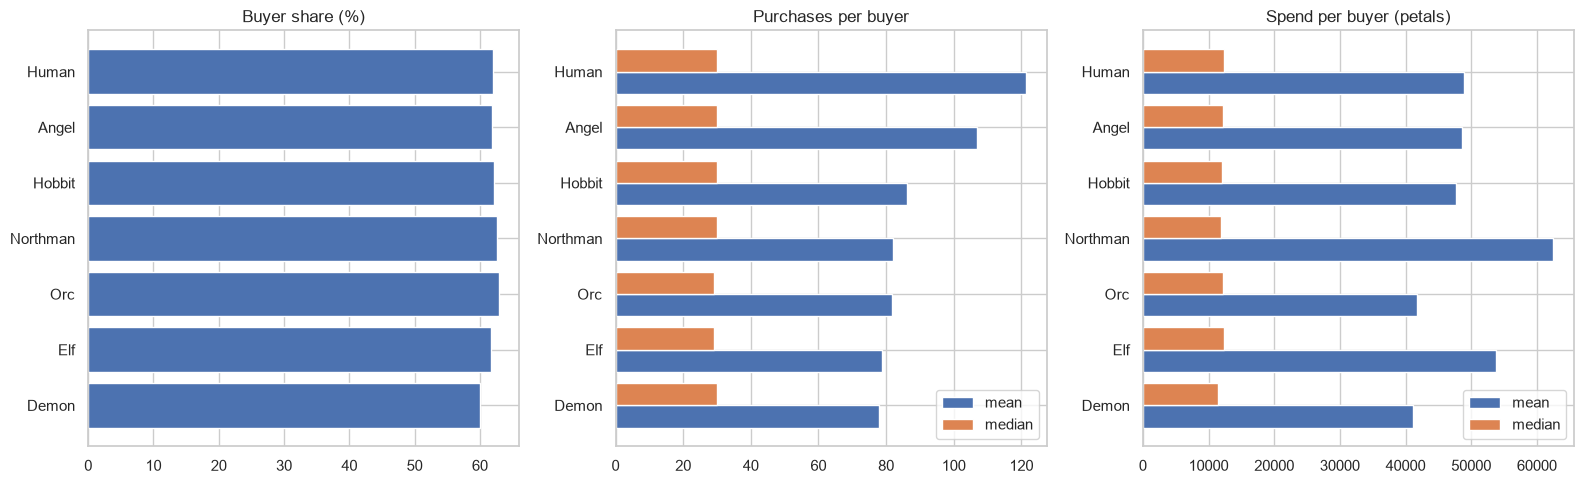

In [109]:
med = players.groupby("race").agg(
    median_purchases=("purchases", "median"),
    median_spend=("total_spend", "median"),
)
d = race_activity.merge(med, left_on="race", right_index=True).sort_values("avg_purchases_per_buyer")
y = np.arange(len(d))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(d["race"], d["buyers_registered_share"] * 100)
axes[0].set_title("Buyer share (%)")

axes[1].barh(y - 0.2, d["avg_purchases_per_buyer"], height=0.4, label="mean")
axes[1].barh(y + 0.2, d["median_purchases"], height=0.4, label="median")
axes[1].set_yticks(y); axes[1].set_yticklabels(d["race"])
axes[1].set_title("Purchases per buyer"); axes[1].legend()

axes[2].barh(y - 0.2, d["spend_per_buyer"], height=0.4, label="mean")
axes[2].barh(y + 0.2, d["median_spend"], height=0.4, label="median")
axes[2].set_yticks(y); axes[2].set_yticklabels(d["race"])
axes[2].set_title("Spend per buyer (petals)"); axes[2].legend()

plt.tight_layout()
plt.savefig("../images/race_activity.png", dpi=150)
plt.show()

In [110]:
# Means vs medians per race. With a heavy tail these can diverge sharply —
# a single outlier moves the mean but not the median.
summary = players.groupby("race").agg(
    buyers=("purchases", "size"),
    mean_purchases=("purchases", "mean"),
    median_purchases=("purchases", "median"),
    max_purchases=("purchases", "max"),
    mean_spend=("total_spend", "mean"),
    median_spend=("total_spend", "median"),
).round(1)
display(summary)

for col, label in [("mean_purchases", "mean"), ("median_purchases", "median")]:
    lo, hi = summary[col].min(), summary[col].max()
    print(f"purchases per buyer, {label:6}: {lo:>7,.1f} – {hi:>7,.1f}  spread {(hi/lo-1)*100:5.1f}%")

# Kruskal-Wallis: rank-based, so unaffected by the extreme tail that
# destabilises the means. Tests whether the distributions differ at all.
groups = [g["purchases"].to_numpy() for _, g in players.groupby("race")]
print(f"\nKruskal-Wallis, purchases per buyer: p = {stats.kruskal(*groups).pvalue:.4f}")

groups_spend = [g["total_spend"].to_numpy() for _, g in players.groupby("race")]
print(f"Kruskal-Wallis, spend per buyer:    p = {stats.kruskal(*groups_spend).pvalue:.4f}")

,buyers,mean_purchases,median_purchases,max_purchases,mean_spend,median_spend
race,,,,,,
Angel,820,106.800,30.000,10828,"48,668.700","12,206.200"
Demon,737,77.900,30.000,13084,"41,197.400","11,454.200"
Elf,1543,78.800,29.000,24010,"53,761.700","12,352.700"
Hobbit,2266,86.100,30.000,13591,"47,620.900","12,097.300"
Human,3921,121.400,30.000,88304,"48,941.000","12,316.200"
Northman,2229,82.100,30.000,13601,"62,520.700","11,865.900"
Orc,2276,81.700,29.000,22778,"41,760.000","12,203.400"


purchases per buyer, mean  :    77.9 –   121.4  spread  55.8%
purchases per buyer, median:    29.0 –    30.0  spread   3.4%

Kruskal-Wallis, purchases per buyer: p = 0.9494
Kruskal-Wallis, spend per buyer:    p = 0.9048


**What the data shows.** On means, purchases per buyer range from 77.9 (Demon) to 121.4
(Human) — an apparent spread of 55.9%, which would suggest a serious balance problem.

**On medians, that spread disappears:** every race sits at 29–30 purchases, a spread of 3.4%.
A Kruskal-Wallis test — rank-based, and therefore not destabilised by the tail — returns
**p = 0.949** for purchases per buyer and **p = 0.905** for spend per buyer. The distributions
are statistically indistinguishable across races.

**What produced the illusion.** The Human group contains a player with 88,304 purchases against
a group median of 30. A single account of this size moves the group mean by tens of purchases
while leaving the median untouched. The 55.9% "spread" is one outlier, not a design imbalance.

**Answer to the request.** The developers' assumption of approximate parity **is supported**.
No race requires materially more epic item purchases to progress. Buyer share is likewise
near-uniform at 60.0–62.9% (spread 4.9%). No rebalancing is indicated by this data.

**Secondary observation.** Payer share among buyers is 17.72%, essentially identical to the
17.69% payer share across the whole registered base. Spending petals in-game carries almost no
information about willingness to pay real money — the two behaviours are close to independent.

**Limitations.**
- Race is chosen by the player, not assigned at random, so even a genuine difference could
  reflect self-selection rather than game design. None was found, so this does not bite here.
- The 88,304-purchase account should be reviewed as a possible data quality issue (bot, test
  account, or aggregation artifact) before any of these aggregates are used in production.
- The smallest race group has 1,229 registered players; effects below roughly 34% relative
  could not be detected at that size (see section 4).

## 4. Metric Validation and Experiment Design

Sections 1–3 describe what the product currently does. This section asks which effects are
**detectable at all** on this audience, and therefore which of the marketing team's proposed
changes are worth testing.

No experiment was run in the game. Historical data is used as a testbed:

1. **A/A simulation** — players split at random with no treatment. Since no true effect exists
   by construction, a correctly calibrated test must reject in ~5% of runs and produce
   uniformly distributed p-values.
2. **MDE** — the minimum detectable effect at the current audience size.
3. **Power simulation** — a synthetic effect is injected into one group.

Two candidate metrics are evaluated: **real-money conversion** (binary, the revenue-bearing
metric) and **in-game spend per buyer** (continuous, heavy-tailed).

In [111]:
import numpy as np
from scipy import stats

ALPHA, POWER, N_SIM, SEED = 0.05, 0.80, 1000, 42
z_a, z_b = stats.norm.ppf(1 - ALPHA / 2), stats.norm.ppf(POWER)

players = pd.read_csv("player_spend.csv")
spend = players["total_spend"].to_numpy(float)

print(f"Buyers: {len(spend):,}")
print(f"Mean {spend.mean():,.1f} | Median {np.median(spend):,.1f} | "
      f"P90 {np.quantile(spend, 0.9):,.1f} | Max {spend.max():,.1f}")
print(f"CV: {spend.std(ddof=1) / spend.mean():.2f}")

Buyers: 13,792
Mean 49,843.1 | Median 12,167.8 | P90 90,977.5 | Max 28,474,180.0
CV: 6.03


In [112]:
def aa_pvalues(values, n_sim=N_SIM, seed=SEED):
    """Random A/A split, n_sim times. No treatment is applied, so the share of
    runs with p < alpha estimates the test's actual type I error rate here."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    n = len(values)
    out = np.empty(n_sim)
    for i in range(n_sim):
        mask = rng.permutation(n) < n // 2
        out[i] = stats.ttest_ind(values[mask], values[~mask], equal_var=False).pvalue
    return out

pv = aa_pvalues(spend)
print(f"Observed FPR: {(pv < ALPHA).mean():.3f} (nominal {ALPHA})")
print(f"KS test for uniformity: p = {stats.kstest(pv, 'uniform').pvalue:.3f}")

Observed FPR: 0.026 (nominal 0.05)
KS test for uniformity: p = 0.000


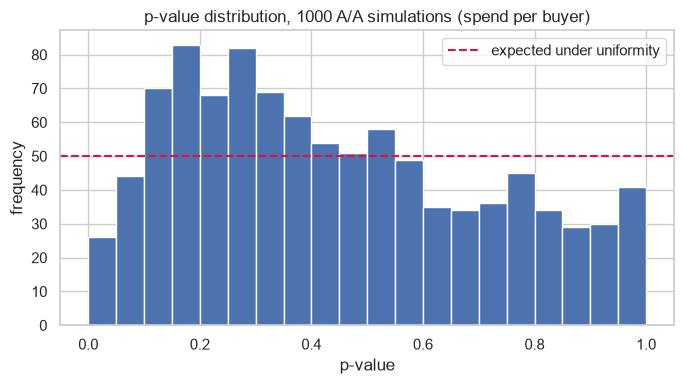

In [113]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pv, bins=20, range=(0, 1), edgecolor="white")
ax.axhline(N_SIM / 20, ls="--", color="crimson", lw=1.5, label="expected under uniformity")
ax.set_xlabel("p-value"); ax.set_ylabel("frequency")
ax.set_title(f"p-value distribution, {N_SIM} A/A simulations (spend per buyer)")
ax.legend(); plt.tight_layout()
plt.savefig("../images/aa_pvalue_distribution.png", dpi=150)
plt.show()

In [114]:
# MDE for both candidate metrics, at the audience size actually available.

# Continuous metric: spend per buyer
n_grp = len(spend) // 2
mde_spend = (z_a + z_b) * np.sqrt(2 * spend.var(ddof=1) / n_grp)

# Binary metric: real-money conversion across the full registered base
p0, n_conv = 3929 / 22214, 22214 // 2
mde_conv = (z_a + z_b) * np.sqrt(2 * p0 * (1 - p0) / n_conv)

print(f"Spend per buyer   n/group {n_grp:>6,}: MDE {mde_spend/spend.mean()*100:5.1f}% relative")
print(f"Conversion        n/group {n_conv:>6,}: MDE {mde_conv*100:5.2f} pp = "
      f"{mde_conv/p0*100:.1f}% relative")

# Smallest race group, to check whether per-race testing is viable
n_race = 1229 // 2
mde_race = (z_a + z_b) * np.sqrt(2 * p0 * (1 - p0) / n_race)
print(f"Conversion, smallest race n/group {n_race:>5,}: MDE {mde_race/p0*100:.1f}% relative")

Spend per buyer   n/group  6,896: MDE  28.8% relative
Conversion        n/group 11,107: MDE  1.43 pp = 8.1% relative
Conversion, smallest race n/group   614: MDE 34.5% relative


In [115]:
def power_sim(values, effect, n_sim=500, seed=SEED + 1):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    n, rejected = len(values), 0
    for _ in range(n_sim):
        mask = rng.permutation(n) < n // 2
        rejected += stats.ttest_ind(values[mask], values[~mask] * (1 + effect),
                                    equal_var=False).pvalue < ALPHA
    return rejected / n_sim

cap = np.quantile(spend, 0.99)
spend_w = np.clip(spend, None, cap)
effects = [0.05, 0.10, 0.20, 0.40]

power_df = pd.DataFrame({
    "effect": [f"{e:.0%}" for e in effects],
    "power (raw)":        [power_sim(spend, e) for e in effects],
    "power (winsorized)": [power_sim(spend_w, e) for e in effects],
})
power_df

,effect,power (raw),power (winsorized)
0,5%,0.060,0.212
1,10%,0.146,0.716
2,20%,0.428,0.998
3,40%,0.940,1.000


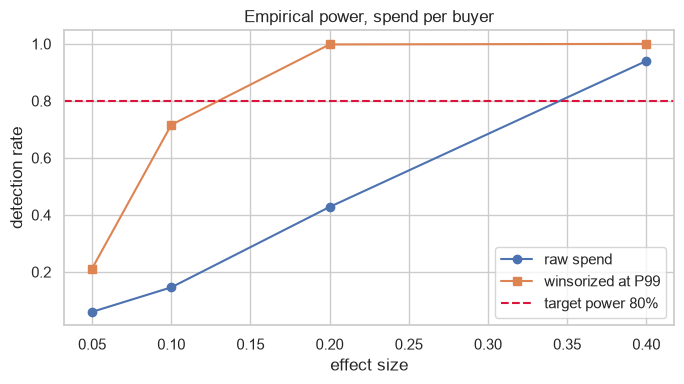

In [116]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(effects, power_df["power (raw)"], "o-", label="raw spend")
ax.plot(effects, power_df["power (winsorized)"], "s-", label="winsorized at P99")
ax.axhline(0.8, ls="--", color="crimson", lw=1.5, label="target power 80%")
ax.set_xlabel("effect size"); ax.set_ylabel("detection rate")
ax.set_title("Empirical power, spend per buyer")
ax.legend(); plt.tight_layout()
plt.savefig("../images/power_curve.png", dpi=150)
plt.show()

### Key Findings

- **Welch's t-test is NOT correctly calibrated on raw spend per buyer.** Across 1,000 A/A
  simulations the observed false positive rate was **2.6%** against a nominal 5%, and the
  p-value distribution failed a uniformity test (**KS p < 0.0001**). The test is *conservative*
  here, not permissive.
- **Cause.** Spend per buyer has skewness 64.6 and excess kurtosis 5,839; the largest value
  exceeds the mean by a factor of 571. Whichever group receives an extreme account acquires an
  inflated sample variance, the standard error grows, and the test stops rejecting. This is a
  failure of the normal approximation, not of the sample size.
- **Transformations restore calibration and cut the MDE substantially:**

  | Metric | FPR | KS p | CV | MDE |
  |---|---|---|---|---|
  | raw | 0.026 | <0.0001 | 6.03 | 28.8% |
  | winsorized P99 | 0.056 | 0.62 | 2.22 | 10.6% |
  | winsorized P95 | 0.047 | 0.80 | 1.44 | 6.9% |
  | log1p | 0.052 | 0.89 | 0.22 | 1.0% |
  | Mann-Whitney | 0.053 | 0.24 | — | — |

- **Real-money conversion remains the better experiment metric.** As a binary metric on the
  full registered base (11,107 per group at p = 0.177) its MDE is **1.43 pp = 8.1% relative**,
  with no distributional assumptions to violate. It is also the only revenue-bearing metric in
  the schema.
- **Per-race testing is not viable.** The smallest race group supports an MDE of ~34% relative
  on conversion. Combined with the null result in section 1, this closes the question of
  race-based targeting.

**Recommendation.** Run advertising experiments on the full registered base with real-money
conversion as the primary metric. If in-game spend must be a decision metric, use a winsorized
or log-transformed version, or a rank-based test — never the raw mean, which under-rejects and
would silently kill true effects.